<div style="background: linear-gradient(135deg, #1e1b4b, #312e81); color:white; padding:25px; border-radius:10px; 
            text-align:center; font-family:'Segoe UI', sans-serif;">

  <h1 style="margin-bottom:8px;"> WikiArt Image Classification</h1>
  <h3 style="margin-top:0; font-style:italic; font-weight:normal; color:#a5b4fc;">
    Baseline CNN
  </h3>

  <hr style="width:60%; border:1px solid #6366f1; margin:15px auto;">

  <p style="margin:5px 0; font-size:15px;">
    <b>Group Project</b> - Deep Learning (2025/2026)
  </p>
  <p style="margin:0; font-size:13px; color:#c7d2fe;">
    Master in Data Science and Advanced Analytics - Nova Information Management School
  </p>
</div>

<br>

<div style="background-color:#1e293b; color:#e0e7ff; padding:15px 20px; border-left:5px solid #6366f1; 
            border-radius:6px; font-family:'Segoe UI', sans-serif; font-size:14px;">
<b>Notebook Description</b><br>
This notebook presents a baseline implementation of a Convolutional Neural Network (CNN) for image classification on the WikiArt dataset.
</div>

<br>

## 1.1 Libraries imports

In [1]:
import os
import sys
import tensorflow as tf
import keras
from keras import layers

# Auto-reload local modules while editing this notebook
%load_ext autoreload
%autoreload 2

sys.path.append(os.path.abspath('../src'))

from utils import (
    build_standard_augmentation,
    build_standard_callbacks,
    evaluate_model,
    load_config,
    load_datasets,
    plot_learning_curves,
    prepare_dataset_pipeline,
    save_history,
    set_seeds,
)

# Load config (relative to notebooks/)
config = load_config('../config.yml')
    
SEED = config['seed']
set_seeds(SEED)

I0000 00:00:1776532651.116188   57318 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


<div id="4-model" style="background-color:#1e293b; padding:18px; border-radius:6px;">
  <h2 style="margin:0; color:#a5b4fc;">
    Model Implementation
  </h2>
</div>

## Baseline CNN Model

A simple CNN baseline with a small number of layers for fast experimentation:
- Data augmentation + rescaling
- 2 Conv2D + MaxPooling blocks
- GlobalAveragePooling + Dense softmax (23 classes)

In [2]:
IMG_SIZE = tuple(config['img_size'])
BATCH_SIZE = config['batch_size']
NUM_CLASSES = config['num_classes']

# All paths relative to notebooks/
train_dir = config['paths']['train_dir']
val_dir = config['paths']['val_dir']
test_dir = config['paths']['test_dir']

train_ds, val_ds, test_ds, class_names = load_datasets(
    train_dir, val_dir, test_dir,
    img_size=IMG_SIZE, batch_size=BATCH_SIZE,
)

Found 9282 files belonging to 23 classes.


W0000 00:00:1776532654.716536   57318 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
W0000 00:00:1776532654.727633   57318 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1776532654.853116   57318 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5286 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5060, pci bus id: 0000:2b:00.0, compute capability: 12.0a


Found 1980 files belonging to 23 classes.
Found 2012 files belonging to 23 classes.
Classes (23): ['Albrecht_Durer', 'Boris_Kustodiev', 'Camille_Pissarro', 'Childe_Hassam', 'Claude_Monet', 'Edgar_Degas', 'Eugene_Boudin', 'Gustave_Dore', 'Ilya_Repin', 'Ivan_Aivazovsky', 'Ivan_Shishkin', 'John_Singer_Sargent', 'Marc_Chagall', 'Martiros_Saryan', 'Nicholas_Roerich', 'Pablo_Picasso', 'Paul_Cezanne', 'Pierre_Auguste_Renoir', 'Pyotr_Konchalovsky', 'Raphael_Kirchner', 'Rembrandt', 'Salvador_Dali', 'Vincent_van_Gogh']


In [3]:
train_ds, val_ds, test_ds = prepare_dataset_pipeline(
    train_ds, val_ds, test_ds, seed=SEED
)

data_augmentation = build_standard_augmentation()

inputs = keras.Input(shape=(*IMG_SIZE, 3))
x = data_augmentation(inputs)
x = layers.Rescaling(1.0 / 255)(x)

x = layers.Conv2D(32, 3, padding="same", activation="relu")(x)
x = layers.MaxPooling2D()(x)

x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
x = layers.MaxPooling2D()(x)

x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(64, activation="relu")(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

model = keras.Model(inputs, outputs, name="cnn_baseline_small")
model.summary()

Model: "cnn_baseline_small"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 23)             │         1,495 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,047 (97.84 KB)

 Trainable params: 25,047 (97.84 KB)

 Non-trainable params: 0 (0.00 B)

### Training

In [4]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy", keras.metrics.F1Score(average="macro", name="f1_macro")],
)

# Save model in models directory (relative to notebooks/)
callbacks = build_standard_callbacks(
    checkpoint_path=config['models']['baseline']['checkpoint'],
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=config['max_epochs'],
    callbacks=callbacks,
)

Epoch 1/200


I0000 00:00:1776532664.659903   57417 cuda_dnn.cc:461] Loaded cuDNN version 92000


289/291 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.0838 - f1_macro: 0.0108 - loss: 3.1153
Epoch 1: val_loss improved from None to 3.02775, saving model to ../models/baseline/baseline_best.keras

Epoch 1: finished saving model to ../models/baseline/baseline_best.keras
291/291 ━━━━━━━━━━━━━━━━━━━━ 17s 26ms/step - accuracy: 0.0919 - f1_macro: 0.0105 - loss: 3.0867 - val_accuracy: 0.1045 - val_f1_macro: 0.0142 - val_loss: 3.0277 - learning_rate: 1.0000e-04
Epoch 2/200
290/291 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.1114 - f1_macro: 0.0162 - loss: 3.0227
Epoch 2: val_loss improved from 3.02775 to 2.96859, saving model to ../models/baseline/baseline_best.keras

Epoch 2: finished saving model to ../models/baseline/baseline_best.keras
291/291 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step - accuracy: 0.1225 - f1_macro: 0.0179 - loss: 3.0076 - val_accuracy: 0.1263 - val_f1_macro: 0.0183 - val_loss: 2.9686 - learning_rate: 1.0000e-04
Epoch 3/200
290/291 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accura

### Learning Curves

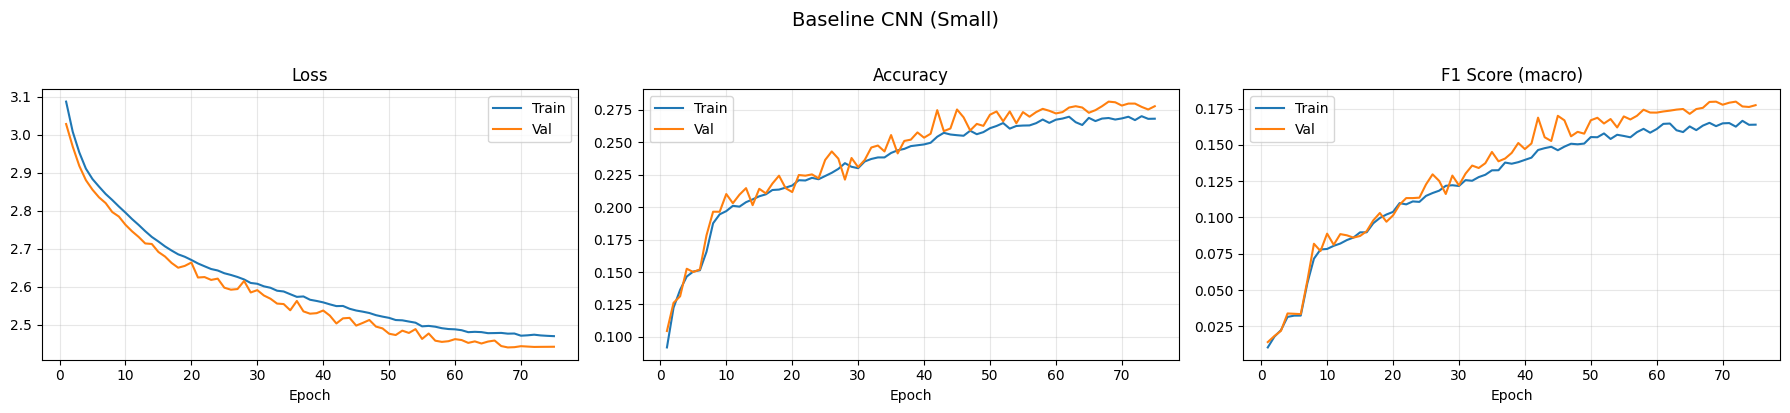

Best epoch (lowest val_loss): 68
  Val Loss: 2.4399
  Val Acc:  0.2813
  Val F1:   0.1795


In [5]:
plot_learning_curves(history, title="Baseline CNN (Small)")

### Test Evaluation


  Baseline CNN (Small) - Test Evaluation
  Test Loss:     2.4927
  Test Accuracy: 0.2584
  Test F1 Macro: 0.1602

Classification Report:
                       precision    recall  f1-score   support

       Albrecht_Durer       0.33      0.38      0.35        87
      Boris_Kustodiev       0.00      0.00      0.00        67
     Camille_Pissarro       0.07      0.02      0.03        93
        Childe_Hassam       0.00      0.00      0.00        58
         Claude_Monet       0.21      0.33      0.25       141
          Edgar_Degas       0.00      0.00      0.00        65
        Eugene_Boudin       0.00      0.00      0.00        59
         Gustave_Dore       0.42      0.90      0.58        80
           Ilya_Repin       0.30      0.17      0.22        58
      Ivan_Aivazovsky       1.00      0.02      0.03        61
        Ivan_Shishkin       0.50      0.11      0.18        55
  John_Singer_Sargent       0.36      0.28      0.31        83
         Marc_Chagall       0.00      0.00

/home/lucas/Desktop/Deep-learning-project/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/lucas/Desktop/Deep-learning-project/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/lucas/Desktop/Deep-learning-project/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _

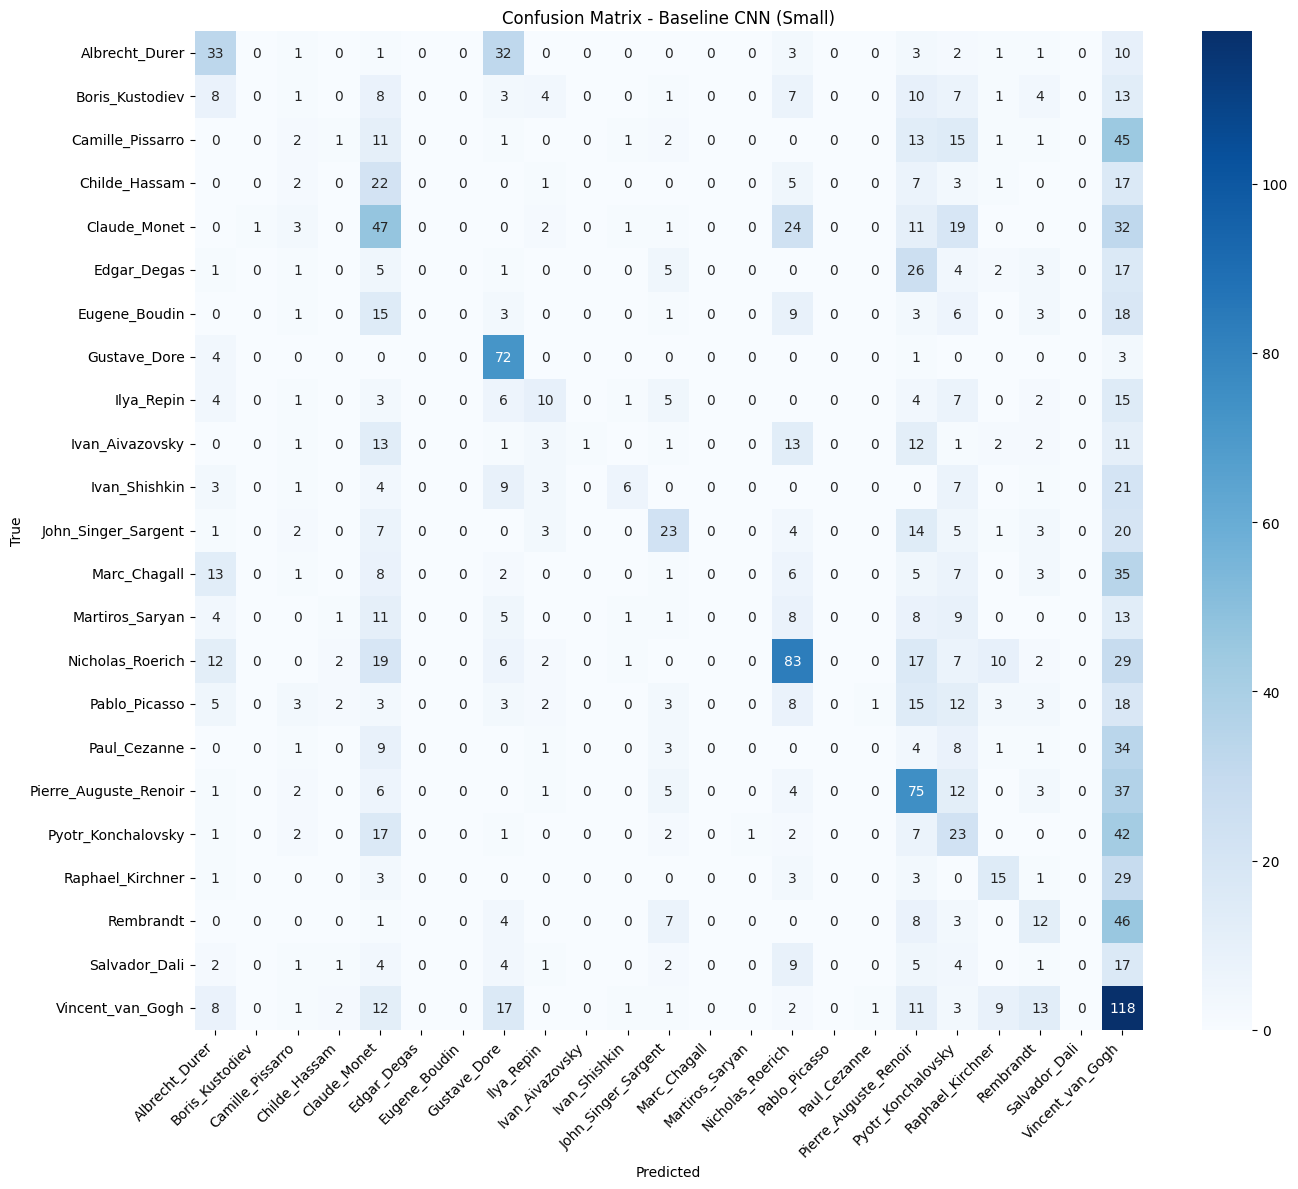

/home/lucas/Desktop/Deep-learning-project/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/lucas/Desktop/Deep-learning-project/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/lucas/Desktop/Deep-learning-project/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _

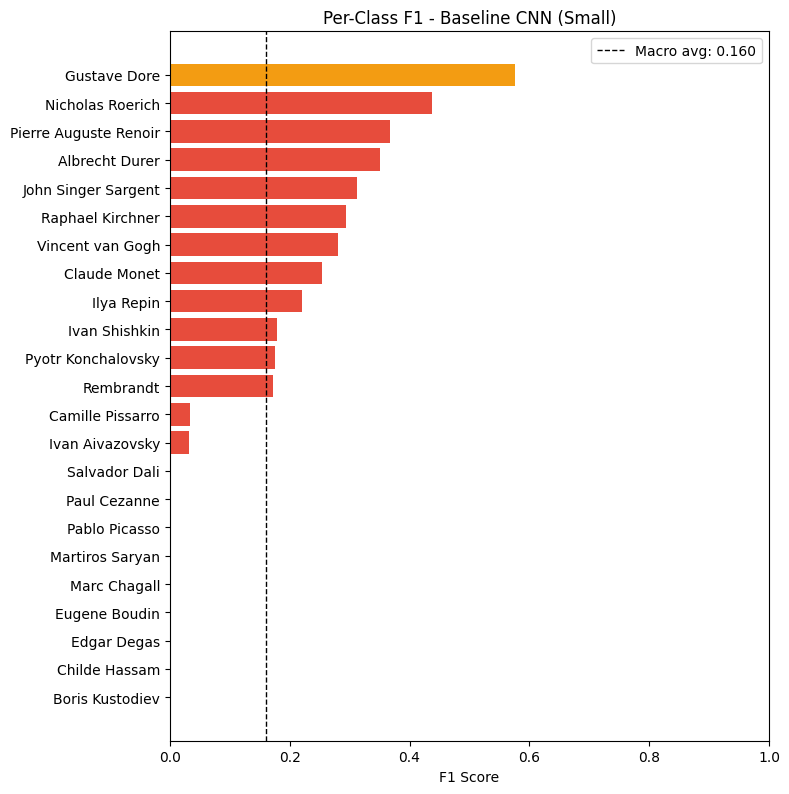

In [6]:
metrics_cnn = evaluate_model(model, test_ds, class_names, "Baseline CNN (Small)")

In [8]:
history_path = config['models']['baseline']['history']
os.makedirs(os.path.dirname(history_path), exist_ok=True)
save_history(history, history_path)

History saved to ../models_results/baseline/baseline_history.json
